# ClusterSOM Example: Solar Wind Classification

This notebook demonstrates how to use a pre-trained ClusterSOM model to classify solar wind data into different wind types (CSW, Ejecta, HAW, SSW) and visualize the clustering results. The workflow includes:
1. Loading the trained model and transform fits
2. Loading and preprocessing solar wind data
3. Predicting cluster assignments for new data
4. Visualizing the results in a multivariate time series plot

## Step 1: Setup and Load Model

### Import libraries and define cluster mappings

In [ ]:
from ClusterSOM import *
import pickle
from sklearn.preprocessing import RobustScaler
from robpy.preprocessing import RobustPowerTransformer

cluster_mapping = {0: 'CSW', 1: 'Ejecta', 2: 'HAW', 3: 'SSW'}  
clr = ['darkblue', 'darkorange', 'tan', 'pink']

Load the trained and clustered toroidal SOM model from the pickle file. The model is stored in the variable `csom`.

In [2]:
with open('./models/toroidal_som.pkl', 'rb') as f:
    csom = pickle.load(f)

### Define feature names

Define the original and transformed feature names. The transformed features correspond to the preprocessing applied during training.

In [3]:
features = ['V', 'Np', 'B', 'Tp', 'Texp/Tp', 'Pdyn', 'logBeta', 'B_rms']
transformed_features = ['Vboxcox', 'logNp', 'logB', 'logTp', 'logTexp/Tp', 'logPdyn', 'logBeta', 'logB_rms']

## Step 2: Load Transform Fits

Load the transform fit for the bulk speed (Box-Cox) and the RobustScaler fit in order to transform and scale the new data before inputting them to the trained model. The fits are stored in the variables `boxcox_fit` and `scaler_fit`, respectively.

In [4]:
with open('./transform/transform_v_boxcox.pkl', 'rb') as f:
    boxcox_fit = pickle.load(f)

with open('./transform/robust_scaler_fit.pkl', 'rb') as f:
    scaler_fit = pickle.load(f)

## Step 3: Load and Preprocess Data

Load the data from the "./data/" folder and apply the same transformations used during training to the relevant features. The transformed and scaled data is stored in the variable `scaled_tdf`.

In [5]:
df = pd.read_csv('./data/minimum_example.csv')
tdf = df[['Time']].copy()
tdf['Vboxcox'] = boxcox_fit.transform(df['V'].values.reshape(-1, 1))
tdf['logNp'] = np.log10(df['Np'])
tdf['logB'] = np.log10(df['B'])
tdf['logTp'] = np.log10(df['Tp'])
tdf['logTexp/Tp'] = np.log10(df['Texp/Tp'])
tdf['logPdyn'] = np.log10(df['Pdyn'])
tdf['logBeta'] = df['logBeta']
tdf['logB_rms'] = np.log10(df['B_rms'])

### Scale the transformed features

Apply the RobustScaler fit to normalize the transformed features to the same scale as the training data.

In [6]:
scaled_tdf = pd.DataFrame(scaler_fit.transform(tdf[transformed_features]), columns=transformed_features)

## Step 4: Predict Clusters

Predict the clusters for the new data using the trained and clustered toroidal SOM model. The predicted clusters are stored in the variable `clustering_results`.

In [7]:
clustering_results = csom.predict(scaled_tdf.to_numpy())

Using batch size: 10000


## Step 5: Visualize Clustering Results

Map the predicted cluster numbers to their corresponding wind type names and visualize the clustering results. The clustering results are visualized by plotting the multivariate time series data for each feature, color-coded by cluster type.

In [8]:
df['Cluster'] = clustering_results
df['Wind_Type'] = df['Cluster'].map(cluster_mapping)

### Create formatting dictionary for plot labels

Define a dictionary that maps feature names to their formatted labels for use in the visualization plots.

In [11]:
fdict = {
    'Np': r'$N_p$ [cm$^{-3}$]',
    'logNp': r'log($N_p$ [cm$^{-3}$])',
    'Tp': r'$T_p$ [K]',
    'logTp': r'log($T_p$ [K])',
    'B': r'$B$ [nT]',
    'logB': r'log($B$ [nT])',
    'V': r'$V_p$ [km/s]',
    'Vboxcox': r'$V_p$ [] (Box-Cox)',
    'logBeta': r'log($\beta$)',
    'Pdyn': r'$P_{dyn}$ [nPa]',
    'logPdyn': r'log($P_{dyn}$ [nPa])',
    'B_rms': r'$\sigma_{B_{rms}}$ [nT]',
    'logB_rms': r'log($\sigma_{B_{rms}}$ [nT])',
    'Texp/Tp': r'$T_{exp}/T_p$',
    'logTexp/Tp': r'log($T_{exp}/T_p$)'
}


### Plot clustering results

Configure matplotlib settings and create a time series plot showing all wind features color-coded by cluster assignment. Each subplot represents one feature, and the color indicates which wind type (CSW, Ejecta, HAW, or SSW) was predicted for each time point.

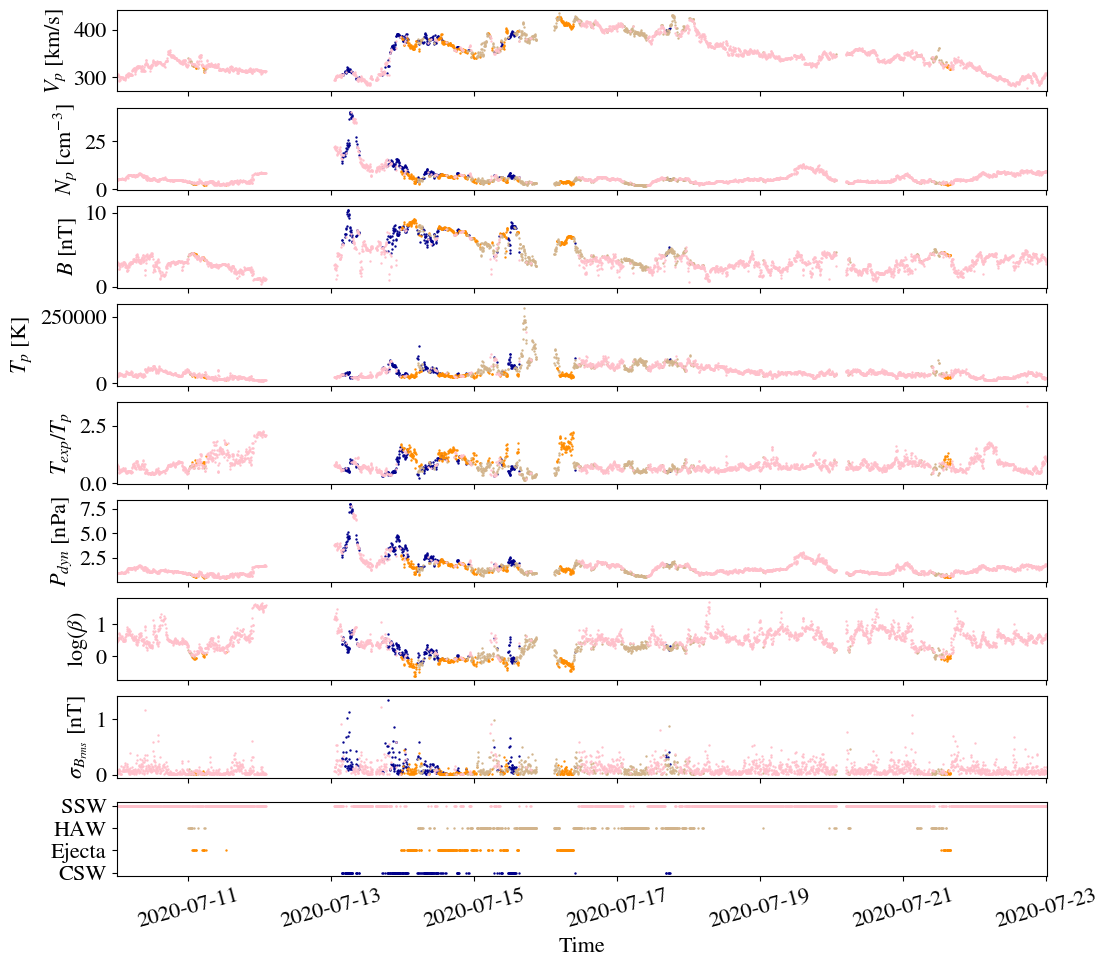

In [14]:
from cluster_som_utils import plot_clusters_timeseries

plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
    "font.serif": ["STIXGeneral"]
})

with plt.rc_context({
    'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'axes.labelsize': 16, 'xtick.labelsize': 16, 'ytick.labelsize': 16,
    'axes.titlesize': 16, 'legend.fontsize': 16
}):
    plot_clusters_timeseries(df, features, fdict, cluster_mapping, clr)